The goal of this notebook is to reproduce Pat Walter's notebook tutorial here: https://github.com/PatWalters/sali/blob/master/sali.ipynb


Minor optimizations:
- Use the new fp generator
- Only calculate the upper triangular similarity matrix to avoid redundant computations

In [1]:
import logging
from IPython.display import SVG, display

import pandas as pd
import numpy as np
from joblib import Parallel, delayed

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, rdFMCS
from rdkit.Chem.Draw import MolsToGridImage

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s | %(message)s"
)
logger = logging.getLogger(__name__)

# Step 1) Load and validate CSV

In [3]:
df = pd.read_csv('activity_data.csv')
df

,SMILES,CID,IC50 (uM),IC50 (uM) - std,Average Inhibition @ 20 uM,Average Inhibition @ 20 uM - std,Average Inhibition @ 50 uM,Average Inhibition @ 50 uM - std,Trypsin IC50 (uM),Relative Solubility @ 20 uM,Relative Solubility @ 100 uM
0,O=C(c1cc(=O)[nH]c2ccccc12)N1CCN(c2ccccc2)CC1,EDJ-MED-78f964c8-1,NaN,NaN,NaN,NaN,NaN,81.80,1.660,NaN,NaN
1,CS(=O)(=O)Nc1cccc(C(=O)Nc2cccc(N3CCCC3=O)c2)c1,MAK-UNK-1e8f9e3c-1,NaN,NaN,NaN,0.866,2.7400,5.19,0.742,1.00,0.99
2,Cc1ccncc1NC(=O)Nc1cccc(Cl)c1,JAG-UCB-cedd89ab-8,68.00,7.10,> 99.0,32.100,0.5390,58.70,0.386,0.99,0.96
3,O=C(CCl)Nc1cccc(N2CCCC2=O)c1,MAK-UNK-7a704a63-10,72.00,13.65,> 49.5,NaN,NaN,NaN,NaN,1.00,1.00
4,O=C(CCl)N1CCN(Cc2ccsc2)CC1,MAK-UNK-212f693e-8,3.27,0.19,> 99.0,NaN,NaN,NaN,NaN,1.00,0.99
...,...,...,...,...,...,...,...,...,...,...,...
305,Cc1ccc(NC(=O)Nc2cccnc2)s1,DAR-DIA-842b4336-3,NaN,NaN,NaN,1.900,0.0997,11.30,0.612,1.00,0.96
306,O=C(Nc1cccnc1)Nc1ccc(Cl)s1,DAR-DIA-842b4336-4,NaN,NaN,NaN,8.850,1.1000,23.70,0.259,0.99,0.95
307,Cc1coc(NC(=O)Nc2cccnc2)n1,DAR-DIA-842b4336-7,NaN,NaN,NaN,2.910,1.5800,8.86,1.000,1.00,1.00
308,O=C(Cc1ccc(Cl)s1)Nc1cccnc1,DAR-DIA-842b4336-13,NaN,NaN,NaN,0.922,2.1900,11.50,1.870,1.00,1.00


In [4]:
# optionally remove any duplicated smiles
before_rows = df.shape[0]
df.drop_duplicates("SMILES",inplace=True)
after_rows = df.shape[0]
print(f"{before_rows} rows reduced to {after_rows} rows")

310 rows reduced to 280 rows


# Step 2) Convert IC50 [nM] or [μM] -> pIC50 [M]

In [5]:
df['IC50 (uM)'].describe()

count    21.000000
mean     38.609048
std      33.063853
min       1.750000
25%       5.660000
50%      28.200000
75%      63.700000
max      99.000000
Name: IC50 (uM), dtype: float64

In [6]:
# nearly all values are missing...
df['IC50 (uM)'].isna().sum()

259

In [7]:
# optionally impute any missing IC50 values with 999 μM 
df.fillna({'IC50 (uM)': 999},inplace=True)

In [8]:
def ic50_nm_to_pic50M(ic50_nm):
    pIC50_M = 9.0 - np.log10(ic50_nm)
    return pIC50_M

In [9]:
def ic50_um_to_pic50M(ic50_nm):
    pIC50_M = 6.0 - np.log10(ic50_nm)
    return pIC50_M

In [10]:
# df['pIC50'] = -np.log10([x * 1e-6 for x in data_df['IC50 (uM)'].values])
df['pIC50'] = df['IC50 (uM)'].apply(ic50_um_to_pic50M)

In [11]:
df.pIC50.describe()

count    280.000000
mean       3.127787
std        0.476636
min        3.000435
25%        3.000435
50%        3.000435
75%        3.000435
max        5.756962
Name: pIC50, dtype: float64

<Axes: ylabel='Frequency'>

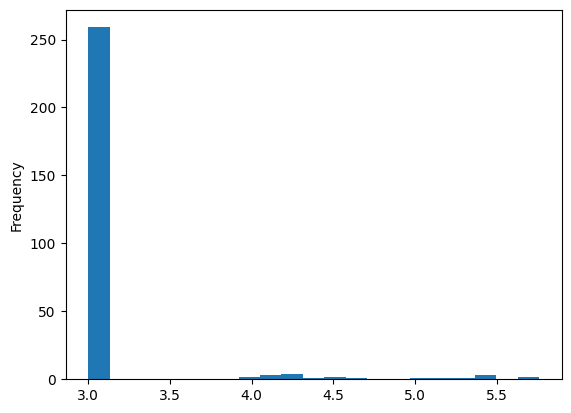

In [12]:
df.pIC50.plot.hist(bins=21)

## 2.1) Additional preprocessing

In [13]:
# Add a RDKit molecule column to the dataframe
df['mol'] = [Chem.MolFromSmiles(x) for x in df.SMILES]

In [14]:
# Add a compound to identify the covalent compounds
chloromethylketone = Chem.MolFromSmarts('C(=O)[CH2]Cl')
acrylamide = Chem.MolFromSmarts('C(=O)[CH]=[CH2]')
df['covalent'] = [x.HasSubstructMatch(acrylamide) or x.HasSubstructMatch(chloromethylketone) for x in df.mol]

In [15]:
df = df.query("covalent == False")
df.shape

(200, 14)

# Step 3) Generate fingerprints in parallel

In [16]:
def get_RDKit_fp_bit(smi: str):
    """Generate a bit vector fingerprint for a given SMILES string."""
    fp_gen = AllChem.GetRDKitFPGenerator(minPath=1, maxPath=7, fpSize=2048)
    mol = Chem.MolFromSmiles(smi)
    # rdkit.DataStructs.cDataStructs.ExplicitBitVect
    return fp_gen.GetFingerprint(mol)

def get_count_RDKit_fp(smi: str):
    """Generate a count vector fingerprint for a given SMILES string."""
    fp_gen = AllChem.GetRDKitFPGenerator(minPath=1, maxPath=7, fpSize=2048)
    mol = Chem.MolFromSmiles(smi)
    # rdkit.DataStructs.cDataStructs.UIntSparseIntVect
    return fp_gen.GetCountFingerprint(mol)

In [17]:
def get_fingerprints(smi_list: list, fp_type: str = "count", n_cpus: int = 1) -> list:
    """
    Generate fingerprints in parallel for a list of SMILES strings.

    Args:
        smi_list: List of SMILES strings.
        fp_type:  Fingerprint type. One of 'count' or 'bit'.
        n_cpus:   Number of parallel workers.
    
    Note:
        - bit vectors produce list of rdkit.DataStructs.cDataStructs.ExplicitBitVect
        - count vectors produce list of rdkit.DataStructs.UIntSparseIntVect
    """
    fp_type = fp_type.lower()
    fp_fn = {"count": get_count_RDKit_fp, "bit": get_RDKit_fp_bit}
    if fp_type not in fp_fn:
        raise ValueError(f"Unknown fp_type '{fp_type}'. Choose from: {list(fp_fn)}")
    
    fp_list = Parallel(n_jobs=n_cpus, backend="loky", verbose=5)(
        delayed(fp_fn[fp_type])(smi) for smi in smi_list
    )

    return fp_list

In [18]:
df.shape

(200, 14)

In [19]:
# Pat Walters uses this function
# I can reproduce as long as I use the same default parameters of minPath=1, maxPath=7, fpSize=2048, and nBitsPerHash=2
# fp_list = [Chem.RDKFingerprint(x) for x in df.mol]
# len(fp_list)

In [20]:
fp_list = get_fingerprints(
        smi_list=df["SMILES"].tolist(),
        fp_type="bit",
        n_cpus=1,
    )
len(fp_list)

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.1s


200

# Define similarity functions

In [21]:
def _bulk_tanimoto(fp, fp_list):
    """
    Thin wrapper around DataStructs.BulkTanimotoSimilarity required because
    Boost.Python functions cannot be pickled by joblib's loky backend.

    T(A, B) = c / (a + b - c)
    c = number of bits in common (intersection of a and b)
    """
    return DataStructs.BulkTanimotoSimilarity(fp, fp_list)

def _bulk_dice(fp, fp_list):
    """
    Thin wrapper around DataStructs.BulkDiceSimilarity required because
    Boost.Python functions cannot be pickled by joblib's loky backend.

    D(A, B) = 2c / (a + b)
    c = number of bits in common (intersection of a and b)

    Since Dice normalizes by the average number of bits rather than the union,
    Dice values are always greater than or equal to Tanimoto values, which
    can compress the dynamic range at high similarity.

    Studies have shown that for many common fingerprint types, Tanimoto and Dice produce nearly identical rankings, meaning they often identify the same compounds as being the "most similar"
    """
    return DataStructs.BulkDiceSimilarity(fp, fp_list)

_METRIC_FNS = {
    "tanimoto": _bulk_tanimoto,
    "dice":     _bulk_dice,
}

def get_similarity_fn(metric: str = "tanimoto"):
    """Return the bulk similarity callable for the given metric."""
    metric = metric.lower()
    if metric not in _METRIC_FNS:
        raise ValueError(f"Unknown metric '{metric}'. Choose from: {list(_METRIC_FNS)}")

    metric_fn = _METRIC_FNS[metric]
    return metric_fn

# Step 4) Identify any compounds with identical smiles and different potency

In [22]:
def log_identical_smiles_groups(smiles: list[str]) -> None:
    """
    Log metadata about compounds that share identical SMILES strings.

    Databases may contain compounds with different IDs and different
    pIC50 values but the same SMILES due to unresolved stereochemistry.
    These pairs produce Sim = 1.0 and are retained in SALI calculation
    since denominator includes epsilon). The function logs how many
    groups of identical SMILES exist and their sizes.
    """
    counts = Counter(smiles)
    duplicated = {smi: n for smi, n in counts.items() if n > 1}

    if not duplicated:
        logger.info("No duplicate SMILES found in dataset.")
        return

    n_groups = len(duplicated)
    group_sizes = sorted(duplicated.values(), reverse=True)
    n_affected = sum(group_sizes)

    logger.warning(
        f"Found {n_groups} group(s) of identical SMILES affecting {n_affected} compounds.\n"
        f"Group sizes: {group_sizes}.\n"
        f"These pairs will have Sim = 1.0 and may reflect unresolved stereochemistry.\n"
        f"SALI is still computed using denominator epsilon (default 0.001)."
    )

In [23]:
# this is expected because we removed duplicates at the start
log_identical_smiles_groups(df["SMILES"].tolist())

INFO | No duplicate SMILES found in dataset.


# Step 5) Compute upper triangle similarities and then apply SALI formula

In [24]:
def _upper_triangle_row(i: int, fp_list: list, metric_fn) -> list[float]:
    """
    Compute similarities for one upper-triangle row.

    For row i, compares fp_list[i] against fp_list[i+1:] only.
    This gives exactly the upper-triangle entries for row i, and
    avoids calculating the diagonal and all (j, i) mirror pairs.

    Returns a list of length (N - i - 1).
    Called in parallel by joblib across all rows i in [0, N-2].
    """
    return metric_fn(fp_list[i], fp_list[i + 1:])

In [25]:
def compute_sali(
    smiles: list[str],
    pic50: np.ndarray,
    fp_list: list,
    metric: str = "tanimoto",
    n_cpus: int = 1,
    sali_epsilon: float = 0.001
) -> pd.DataFrame:
    """
    Compute SALI for all unique upper-triangle pairs (i < j).

    For each row i, BulkTanimotoSimilarity(fp_i, fp_list[i+1:]) is called,
    giving exactly N*(N-1)/2 similarity calculations with no redundancy.
    Avoids building the full N x N matrix and then discarding half i.e.,
    self-similarity diagonal entries and all (j, i) mirror pairs
    
    Rows are dispatched in parallel via joblib.The variable-length row results
    are then flattened and paired with pre-computed (i, j) index arrays.

    The SALI formula used is:
        SALI(i,j) = |pIC50_i - pIC50_j| / (1 - Sim(i,j) + 0.001)

    The epsilon avoids division by zero for identical fingerprints (Sim=1.0)
    
    Note: NaN pIC50 values are excluded before computation. It is the
    caller's responsibility to handle missing values before calling this
    function (e.g. impute, drop, or investigate in a notebook).
    
    Args:
        smiles: list of SMILES strings. Length must equal len(pic50).
        pic50: array of pIC50 values in Molar units.
        fp_list: list of RDKit fingerprint objects. Type must be ExplicitBitVect or UIntSparseIntVect for similarity calculation.
        metric: similarity metric, 'tanimoto' (default) or 'dice'.
        n_cpus: number of parallel workers.
        sali_epsilon: epsilon added to denominator to avoid division by zero at Sim = 1.0.

    Returns:
        pd.DataFrame with Columns
            ['compound_i', 'compound_j', 'SMILES_i', 'SMILES_j',
             'pIC50_i', 'pIC50_j', 'delta_pIC50',
             '{metric}_similarity', 'SALI']
        compound_i/j are the original integer positions in the input lists.
        Output is sorted by SALI descending.
    """
    # validate the inputs
    n = len(smiles)
    if len(pic50) != n or len(fp_list) != n:
        raise ValueError(
            f"smiles ({len(smiles)}), pic50 ({len(pic50)}), and "
            f"fp_list ({len(fp_list)}) must all be the same length."
        )
    metric_fn = get_similarity_fn(metric)
    
    # log any identical smiles
    log_identical_smiles_groups(smiles)

    # exclude any compounds with missing pIC50
    pic50 = np.asarray(pic50, dtype=float)
    smiles_arr = np.asarray(smiles, dtype=object)

    valid_mask = ~np.isnan(pic50)
    n_invalid  = (~valid_mask).sum()
    if n_invalid > 0:
        logger.warning(
            f"Excluding {n_invalid} compound(s) with NaN pIC50. "
            "Handle missing values in your notebook before calling this function."
        )

    valid_indices = np.where(valid_mask)[0]
    fp_list_valid = [fp_list[i] for i in valid_indices]
    pic50_valid = pic50[valid_mask]
    smiles_valid = smiles_arr[valid_mask]

    n_valid = len(fp_list_valid)
    total_pairs  = n_valid * (n_valid - 1) // 2
    logger.info(
        f"Computing upper-triangle {metric} similarities: "
        f"{n_valid} compounds -> {total_pairs:,} unique pairs "
        f"using {n_cpus} CPU(s)..."
    )

    # Parallel upper-triangle computation
    # Row i returns similarities to compounds [i+1, i+2, ..., N-1].
    # Row N-1 has no upper-triangle partners, so we stop at N-2.
    row_results = Parallel(n_jobs=n_cpus, backend="loky", batch_size="auto", verbose=5)(
        delayed(_upper_triangle_row)(i, fp_list_valid, metric_fn)
        for i in range(n_valid - 1)
    )
    # row_results[i] has length (N - i - 1):
    # row_results[0] -> N-1 values, row_results[1] -> N-2 values, ..., row_results[N-2] -> 1 value

    # Flatten and align row_results with (rows, cols) index arrays
    # np.triu_indices produces the same row-major ordering as our loop
    rows, cols = np.triu_indices(n_valid, k=1)  # both shape (total_pairs,)
    sim_vals = np.concatenate([np.asarray(r) for r in row_results])  # shape (total_pairs,)
    delta_vals = np.abs(pic50_valid[rows] - pic50_valid[cols])

    # SALI formula with epsilon denominator
    sali_vals = delta_vals / (1.0 - sim_vals + sali_epsilon)

    # Map back to original input positions
    orig_i = valid_indices[rows]
    orig_j = valid_indices[cols]

    df_sali = pd.DataFrame({
        "compound_i":           orig_i,
        "compound_j":           orig_j,
        "SMILES_i":             smiles_valid[rows],
        "SMILES_j":             smiles_valid[cols],
        "pIC50_i":              np.round(pic50_valid[rows], 5),
        "pIC50_j":              np.round(pic50_valid[cols], 5),
        "delta_pIC50":          np.round(delta_vals, 5),
        f"{metric}_similarity": np.round(sim_vals, 5),
        "SALI":                 np.round(sali_vals, 5),
    })

    df_sali = df_sali.sort_values("SALI", ascending=False).reset_index(drop=True)
    logger.info(f"Computed {len(df_sali):,} valid SALI pairs.")
    stats_text = (
        f"n pairs = {len(df_sali):,}\n"
        f"mean = {df_sali.SALI.mean():.2f}\n"
        f"median = {df_sali.SALI.median():.2f}\n"
        f"max = {df_sali.SALI.max():.2f}"
    )
    logger.info(stats_text)

    return df_sali

In [26]:
df.columns

Index(['SMILES', 'CID', 'IC50 (uM)', 'IC50 (uM) - std',
       'Average Inhibition @ 20 uM', 'Average Inhibition @ 20 uM - std',
       'Average Inhibition @ 50 uM', 'Average Inhibition @ 50 uM - std',
       'Trypsin IC50 (uM)', 'Relative Solubility @ 20 uM',
       'Relative Solubility @ 100 uM', 'pIC50', 'mol', 'covalent'],
      dtype='object')

In [27]:
df_sali = compute_sali(
    smiles=df.SMILES.tolist(),
    pic50=df.pIC50.values,
    fp_list=fp_list,
    metric="tanimoto",
    n_cpus=1,
    sali_epsilon=0.001,
    # sali_epsilon=0.05,
    )
df_sali.shape

INFO | No duplicate SMILES found in dataset.
INFO | Computing upper-triangle tanimoto similarities: 200 compounds -> 19,900 unique pairs using 1 CPU(s)...
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
INFO | Computed 19,900 valid SALI pairs.
INFO | n pairs = 19,900
mean = 0.18
median = 0.00
max = 11.83


(19900, 9)

In [28]:
df_sali

,compound_i,compound_j,SMILES_i,SMILES_j,pIC50_i,pIC50_j,delta_pIC50,tanimoto_similarity,SALI
0,40,41,Cc1ccncc1NC(=O)Cc1ccccc1,Cc1ccncc1NC(=O)Cc1cccc(Cl)c1,3.00043,4.59517,1.59473,0.86624,11.83404
1,40,43,Cc1ccncc1NC(=O)Cc1ccccc1,Cc1ccncc1NC(=O)Cc1cccc(C#N)c1,3.00043,4.19586,1.19543,0.86076,8.52411
2,43,170,Cc1ccncc1NC(=O)Cc1cccc(C#N)c1,N#Cc1cccc(CC(=O)Nc2cccnc2)c1,4.19586,3.00043,1.19543,0.84599,7.71201
3,2,39,Cc1ccncc1NC(=O)Nc1cccc(Cl)c1,Cc1ccncc1NC(=O)Nc1ccccc1,4.16749,3.00043,1.16706,0.84352,7.41086
4,0,153,O=C(c1cc(=O)[nH]c2ccccc12)N1CCN(c2ccccc2)CC1,COc1ccccc1OCCNC(=O)c1cc(=O)[nH]c2ccccc12,3.00043,5.15366,2.15323,0.66741,6.45463
...,...,...,...,...,...,...,...,...,...
19895,37,59,O=C(Nc1cccnc1)c1cc(Cl)ccc1O,Cc1ccccc1NC1CCN(c2ccc(S(N)(=O)=O)cc2)CC1,3.00043,3.00043,0.00000,0.20048,0.00000
19896,37,58,O=C(Nc1cccnc1)c1cc(Cl)ccc1O,NS(=O)(=O)c1ccc(N2CCC(Nc3ccccc3)CC2)cc1,3.00043,3.00043,0.00000,0.17179,0.00000
19897,37,57,O=C(Nc1cccnc1)c1cc(Cl)ccc1O,Cc1cccc(NC2CCN(c3ccc(S(N)(=O)=O)cc3)CC2)c1,3.00043,3.00043,0.00000,0.20247,0.00000
19898,37,56,O=C(Nc1cccnc1)c1cc(Cl)ccc1O,NS(=O)(=O)c1ccc(N2CCC(Nc3ccc(F)cc3)CC2)cc1,3.00043,3.00043,0.00000,0.17407,0.00000


In [29]:
# optionally swap the indices so compound i always has larger potency
# assist with visual inspection only
def sort_cliff_pairs_by_potency(df_sali: pd.DataFrame) -> pd.DataFrame:
    """
    Reorder each pair so that compound_i is always the more active compound.

    After compute_sali(), compound_i simply has the lower original index.
    Optionally apply this function to swap compound_i and compound_j 
    (and their associated SMILES and pIC50 columns) so that pIC50_i >= pIC50_j in every row.
    This is purly for easy visual analysis in a notebook.
    The SALI scores, delta_pIC50, and similarity values are symmetric and do not change.

    Args:
        df_sali : pd.DataFrame
        Output of compute_sali(). Must contain columns:
        'compound_i', 'compound_j', 'SMILES_i', 'SMILES_j',
        'pIC50_i', 'pIC50_j'.

    Returns
    pd.DataFrame
        Same shape as input. Rows where pIC50_i < pIC50_j are swapped
        so that pIC50_i >= pIC50_j throughout. Sort order (by SALI) is preserved.
    """
    df = df_sali.copy()
    swap = df["pIC50_i"] < df["pIC50_j"]

    if not swap.any():
        return df

    # swap all paired columns simultaneously
    for col_a, col_b in [
        ("compound_i", "compound_j"),
        ("SMILES_i",   "SMILES_j"),
        ("pIC50_i",    "pIC50_j"),
    ]:
        df.loc[swap, [col_a, col_b]] = df.loc[swap, [col_b, col_a]].values

    logger.info(f"Swapped {swap.sum():,} pairs so that pIC50_i >= pIC50_j throughout.")
    return df

In [30]:
# great this matches Pat Walter's result :)
df_sali_sorted = sort_cliff_pairs_by_potency(df_sali)
df_sali_sorted

INFO | Swapped 850 pairs so that pIC50_i >= pIC50_j throughout.


,compound_i,compound_j,SMILES_i,SMILES_j,pIC50_i,pIC50_j,delta_pIC50,tanimoto_similarity,SALI
0,41,40,Cc1ccncc1NC(=O)Cc1cccc(Cl)c1,Cc1ccncc1NC(=O)Cc1ccccc1,4.59517,3.00043,1.59473,0.86624,11.83404
1,43,40,Cc1ccncc1NC(=O)Cc1cccc(C#N)c1,Cc1ccncc1NC(=O)Cc1ccccc1,4.19586,3.00043,1.19543,0.86076,8.52411
2,43,170,Cc1ccncc1NC(=O)Cc1cccc(C#N)c1,N#Cc1cccc(CC(=O)Nc2cccnc2)c1,4.19586,3.00043,1.19543,0.84599,7.71201
3,2,39,Cc1ccncc1NC(=O)Nc1cccc(Cl)c1,Cc1ccncc1NC(=O)Nc1ccccc1,4.16749,3.00043,1.16706,0.84352,7.41086
4,153,0,COc1ccccc1OCCNC(=O)c1cc(=O)[nH]c2ccccc12,O=C(c1cc(=O)[nH]c2ccccc12)N1CCN(c2ccccc2)CC1,5.15366,3.00043,2.15323,0.66741,6.45463
...,...,...,...,...,...,...,...,...,...
19895,37,59,O=C(Nc1cccnc1)c1cc(Cl)ccc1O,Cc1ccccc1NC1CCN(c2ccc(S(N)(=O)=O)cc2)CC1,3.00043,3.00043,0.00000,0.20048,0.00000
19896,37,58,O=C(Nc1cccnc1)c1cc(Cl)ccc1O,NS(=O)(=O)c1ccc(N2CCC(Nc3ccccc3)CC2)cc1,3.00043,3.00043,0.00000,0.17179,0.00000
19897,37,57,O=C(Nc1cccnc1)c1cc(Cl)ccc1O,Cc1cccc(NC2CCN(c3ccc(S(N)(=O)=O)cc3)CC2)c1,3.00043,3.00043,0.00000,0.20247,0.00000
19898,37,56,O=C(Nc1cccnc1)c1cc(Cl)ccc1O,NS(=O)(=O)c1ccc(N2CCC(Nc3ccc(F)cc3)CC2)cc1,3.00043,3.00043,0.00000,0.17407,0.00000


# Step 6) Visualize the pairs with top SALI values

In [31]:
def align_mols(smi_i, smi_j):
    mol_i = Chem.MolFromSmiles(smi_i)
    mol_j = Chem.MolFromSmiles(smi_j)

    mcs = rdFMCS.FindMCS([mol_i, mol_j], completeRingsOnly=True)
    if mcs.numAtoms > 0:
        mcs_query = Chem.MolFromSmarts(mcs.smartsString)
        AllChem.Compute2DCoords(mcs_query)
        AllChem.GenerateDepictionMatching2DStructure(mol_i, mcs_query)
        AllChem.GenerateDepictionMatching2DStructure(mol_j, mcs_query)
        # GetSubstructMatch returns the atom indices in each mol that
        # correspond to the MCS query — these are the atoms to highlight
        mcs_atoms_i = mol_i.GetSubstructMatch(mcs_query)
        mcs_atoms_j = mol_j.GetSubstructMatch(mcs_query)
    else:
        AllChem.Compute2DCoords(mol_i)
        AllChem.Compute2DCoords(mol_j)
        mcs_atoms_i, mcs_atoms_j = (), ()

    return mol_i, mol_j, mcs_atoms_i, mcs_atoms_j

In [32]:
def _get_mcs_bond_indices(mol, atom_indices: list) -> list:
    """Return indices of bonds where both endpoints are in atom_indices."""
    atom_set = set(atom_indices)
    return [
        bond.GetIdx()
        for bond in mol.GetBonds()
        if bond.GetBeginAtomIdx() in atom_set
        and bond.GetEndAtomIdx() in atom_set
    ]

In [33]:
def show_top_n_cliffs(df_sali: pd.DataFrame, n: int = 5, save_path: str = None):
    """
    Draw the top N activity cliff pairs in a single grid (N rows x 2 columns).

    The more active compound (compound_i, higher pIC50) is always on the left.
    Molecules within each pair are aligned to their Maximum Common Substructure.

    Parameters
    ----------
    df_sali : pd.DataFrame
        SALI dataframe, sorted by SALI descending. Must have columns:
        SMILES_i, SMILES_j, compound_i, compound_j,
        pIC50_i, pIC50_j, delta_pIC50, tanimoto_similarity, SALI.
    n : int
        Number of top pairs to show. Default 5.
    save_path : str, optional
        If provided, saves the image to this path (e.g. 'cliffs.png').

    Returns
    -------
    PIL.Image
    """
    mols, legends, highlight_atoms = [], [], []

    for rank, (_, row) in enumerate(df_sali.head(n).iterrows(), start=1):
        mol_i, mol_j, mcs_i, mcs_j = align_mols(row["SMILES_i"], row["SMILES_j"])
        fold_diff = 10 ** row["delta_pIC50"]
        mols             += [mol_i, mol_j]
        highlight_atoms  += [list(mcs_i), list(mcs_j)]
        legends          += [
            f"#{rank} Compound {row['compound_i']} | pIC50={row['pIC50_i']:.2f} "
            f"| SALI={row['SALI']:.1f} | Tan={row['tanimoto_similarity']:.2f} | {fold_diff:.0f}x",
            f"#{rank} Compound {row['compound_j']} | pIC50={row['pIC50_j']:.2f}",
        ]

    HIGHLIGHT_COLOR = (0.4, 0.9, 0.1)  # bright green
    HIGHLIGHT_COLOR = (0.6, 0.8, 0.6)  # muted sage green
    # build per-atom and per-bond color dicts keyed to actual MCS atom/bond indices
    atom_colors  = [{idx: HIGHLIGHT_COLOR for idx in atom_list} for atom_list in highlight_atoms]
    bond_colors  = [{idx: HIGHLIGHT_COLOR for idx in _get_mcs_bond_indices(mol, atom_list)}
                    for mol, atom_list in zip(mols, highlight_atoms)]

    img = MolsToGridImage(
        mols,
        molsPerRow=2,
        subImgSize=(400, 300),
        legends=legends,
        highlightAtomLists=highlight_atoms,
        highlightAtomColors=atom_colors,
        highlightBondLists=[[] for _ in mols],  # disable bond highlighting
        useSVG=True,
        maxMols=n * 2,
    )

    if save_path:
        with open(save_path, "w") as f:
            f.write(img)

    return img

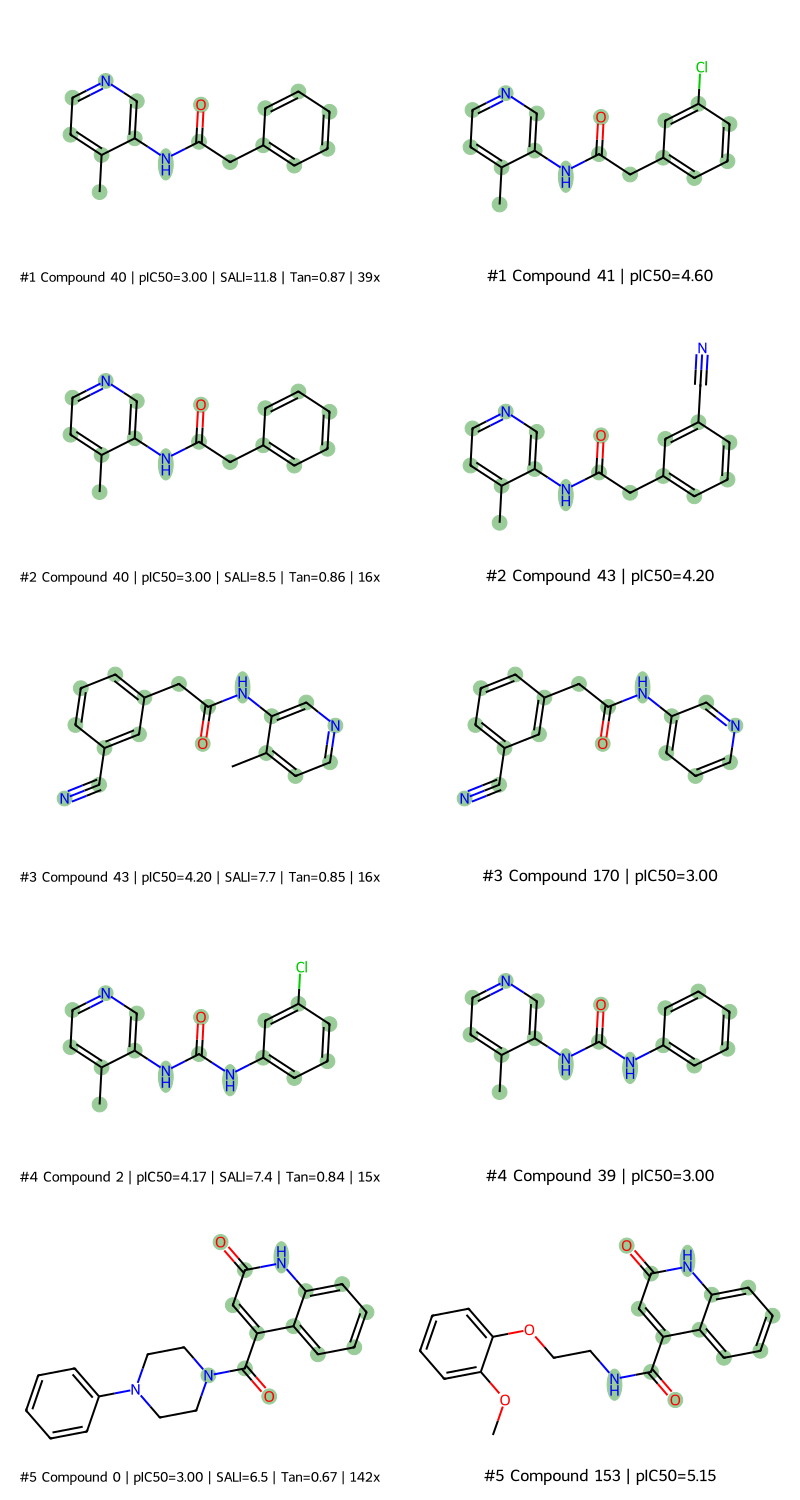

In [34]:
img = show_top_n_cliffs(df_sali,
                        n=5,
                        # save_path="top5_cliffs.png",
                       )
display(img)